# PART 11

Haikal Ali_1103223071_TK46GAB

# Bab 11 - Novelty and Outlier Detection

Notebook ini dibuat dari materi **Novelty and Outlier Detection**. Fokusnya adalah deteksi outlier dan novelty menggunakan scikit-learn, terutama **Local Outlier Factor (LOF)**, **Isolation Forest**, dan **One-Class SVM**.

Materi yang bersifat teori ditulis sebagai markdown. Materi yang memiliki contoh kode ditulis sebagai cell kode.

## Technical requirements

Materi menyarankan penggunaan environment Python yang terisolasi. Kebutuhan teknis yang disebutkan:

- Git >= 2.46.x
- Python >= 3.9.x
- Repository GitHub yang sudah di-clone dan environment Python dari file `requirements.txt`

## Introduction to outlier and novelty detection

Pada sistem machine learning, data produksi tidak selalu sama dengan data training. Data nyata dapat berisi observasi langka, pola baru, noise, atau data yang sengaja dirusak. Nilai seperti ini biasanya dibagi menjadi dua:

- **Outlier**: data yang sangat berbeda dari observasi lain di data training.
- **Novelty**: data baru yang belum pernah terlihat saat training dan baru muncul ketika prediksi.

Deteksi outlier dan novelty penting untuk mencegah prediksi yang menyesatkan, terutama pada kasus seperti fraud detection, industrial monitoring, medical diagnostics, dan model monitoring.

### Membuat dataset sintetis dengan outlier

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, _ = make_blobs(
    n_samples=300,
    centers=1,
    cluster_std=0.60,
    random_state=2024
)

np.random.seed(2024)
outliers = np.random.uniform(low=-6, high=6, size=(20, 2))
X_with_outliers = np.vstack([X, outliers])

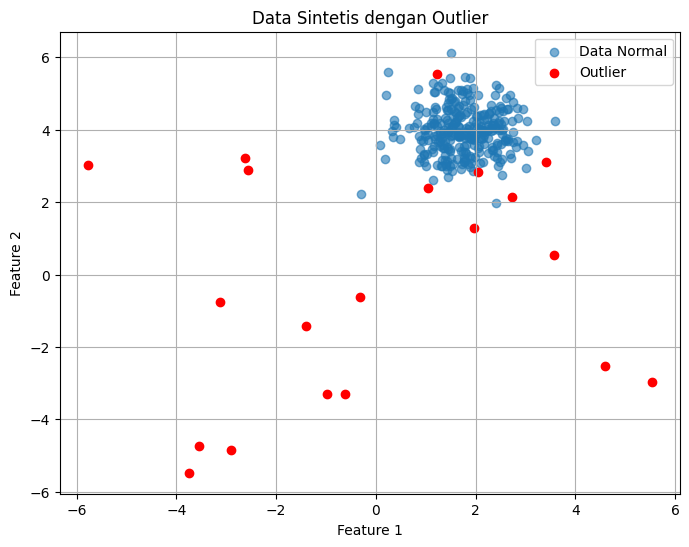

In [2]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X[:, 0], X[:, 1],
    label="Data Normal",
    alpha=0.6
)
plt.scatter(
    outliers[:, 0], outliers[:, 1],
    color='red',
    label="Outlier"
)
plt.title("Data Sintetis dengan Outlier")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

Plot di atas memperlihatkan satu kelompok data normal yang padat dan beberapa titik merah yang berada jauh dari kelompok utama. Titik merah tersebut merepresentasikan kemungkinan outlier.

### Deteksi outlier menggunakan Local Outlier Factor

Local Outlier Factor atau LOF adalah metode unsupervised yang mendeteksi anomali dengan membandingkan kepadatan lokal suatu titik terhadap kepadatan lokal tetangganya.

In [3]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred = lof.fit_predict(X_with_outliers)

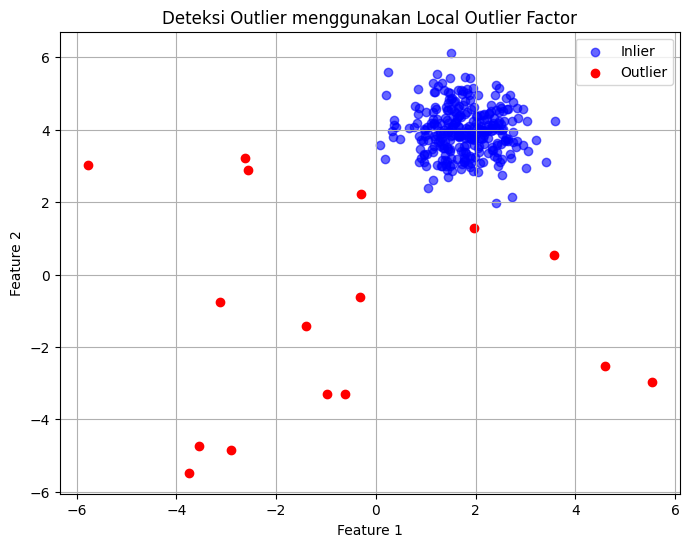

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_with_outliers[y_pred == 1, 0],
    X_with_outliers[y_pred == 1, 1],
    color='blue',
    label='Inlier',
    alpha=0.6
)
plt.scatter(
    X_with_outliers[y_pred == -1, 0],
    X_with_outliers[y_pred == -1, 1],
    color='red',
    label='Outlier'
)
plt.title("Deteksi Outlier menggunakan Local Outlier Factor")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

LOF membedakan titik yang dianggap normal atau **inlier** dan titik yang dianggap anomali atau **outlier**. Parameter `contamination` digunakan untuk memperkirakan proporsi outlier di dataset.

Beberapa konsep penting:

- Outlier dapat muncul pada data training maupun test.
- Novelty hanya muncul pada data baru ketika model digunakan.
- `contamination` membantu model mengatur batas keputusan berdasarkan estimasi proporsi outlier.
- LOF adalah pendekatan berbasis kepadatan lokal.

### Catatan tambahan

Strategi deteksi juga dapat dipengaruhi oleh domain knowledge, feature engineering, scaling, dan kebutuhan monitoring model di production.

## Understanding Isolation Forest

Isolation Forest adalah algoritma yang efisien untuk mendeteksi outlier, termasuk pada dataset berdimensi tinggi. Berbeda dengan metode yang memodelkan data normal terlebih dahulu, Isolation Forest bekerja dengan cara mengisolasi anomali. Outlier cenderung lebih mudah diisolasi karena berbeda dari sebagian besar data.

### Membuat dataset untuk Isolation Forest

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs

X, _ = make_blobs(
    n_samples=300,
    centers=1,
    cluster_std=0.6,
    random_state=2024
)

np.random.seed(2024)
outliers = np.random.uniform(low=-6, high=6, size=(20, 2))
X_combined = np.vstack([X, outliers])

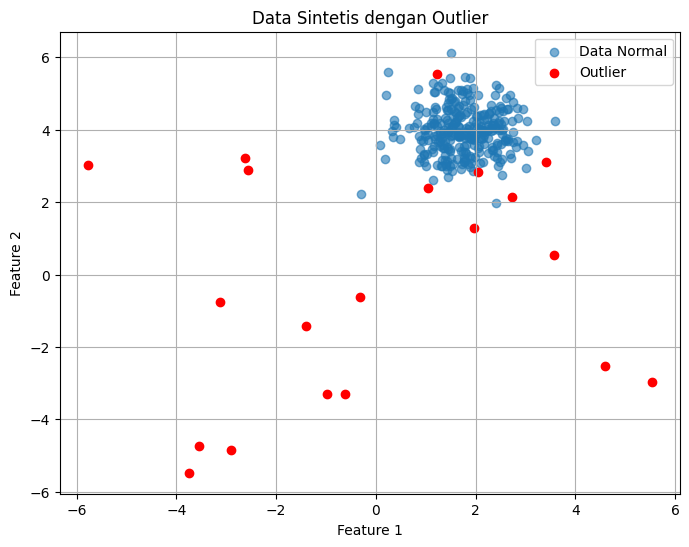

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X[:, 0], X[:, 1],
    label="Data Normal",
    alpha=0.6
)
plt.scatter(
    outliers[:, 0], outliers[:, 1],
    color='red',
    label="Outlier"
)
plt.title("Data Sintetis dengan Outlier")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

Plot di atas menunjukkan data normal yang padat dan sejumlah titik outlier yang menyebar jauh dari pusat distribusi.

### Deteksi outlier menggunakan Isolation Forest

In [7]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=2024
)

In [8]:
model.fit(X_combined)
y_pred = model.predict(X_combined)

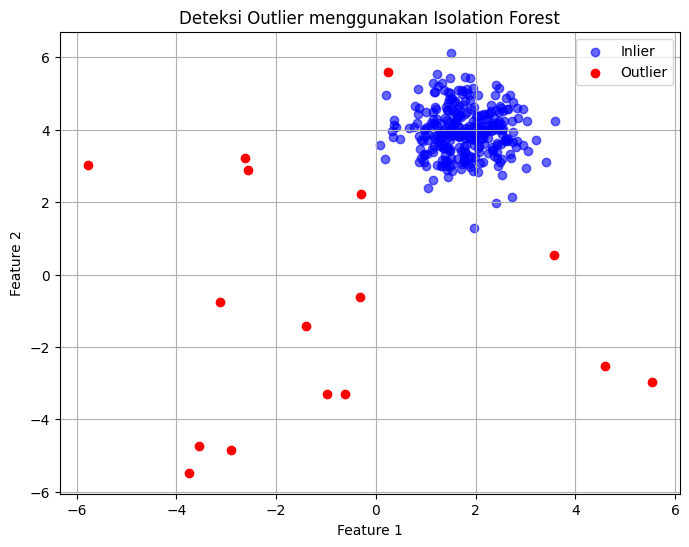

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_combined[y_pred == 1, 0],
    X_combined[y_pred == 1, 1],
    color='blue',
    label='Inlier',
    alpha=0.6
)
plt.scatter(
    X_combined[y_pred == -1, 0],
    X_combined[y_pred == -1, 1],
    color='red',
    label='Outlier'
)
plt.title("Deteksi Outlier menggunakan Isolation Forest")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

Isolation Forest mengklasifikasikan titik normal dan outlier. Mekanisme utamanya:

- **Random splitting**: algoritma memilih feature dan nilai split secara acak.
- **Path length**: skor anomali ditentukan dari panjang jalur rata-rata di banyak tree. Jalur yang lebih pendek mengindikasikan data lebih mudah diisolasi.
- **Contamination**: menentukan estimasi proporsi outlier.

Karena tidak bergantung langsung pada jarak atau kepadatan, Isolation Forest cocok untuk dataset besar dan berdimensi tinggi.

### Catatan tambahan Isolation Forest

- Feature scaling tidak selalu sekrusial metode berbasis jarak, tetapi tetap dapat membantu jika skala feature sangat berbeda.
- `decision_function()` dapat digunakan untuk memperoleh skor anomali kontinu.
- Isolation Forest tidak incremental, tetapi dapat dilatih ulang secara efisien pada batch data baru.

## One-Class SVM for novelty detection

One-Class SVM digunakan untuk novelty detection, terutama ketika data training hanya berisi data normal. Model mempelajari batas normalitas, lalu data baru yang berada di luar batas tersebut dianggap sebagai novelty.

Metode ini cocok untuk kasus ketika contoh anomali sangat jarang atau tidak tersedia saat training.

### Membuat data normal dan data novelty

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

X_train, _ = make_blobs(
    n_samples=300,
    centers=1,
    cluster_std=0.6,
    random_state=2024
)

X_test_normal, _ = make_blobs(
    n_samples=100,
    centers=1,
    cluster_std=0.6,
    center_box=(0, 1),
    random_state=42
)

X_test_novelty = np.random.uniform(low=-6, high=6, size=(20, 2))
X_test = np.vstack([X_test_normal, X_test_novelty])

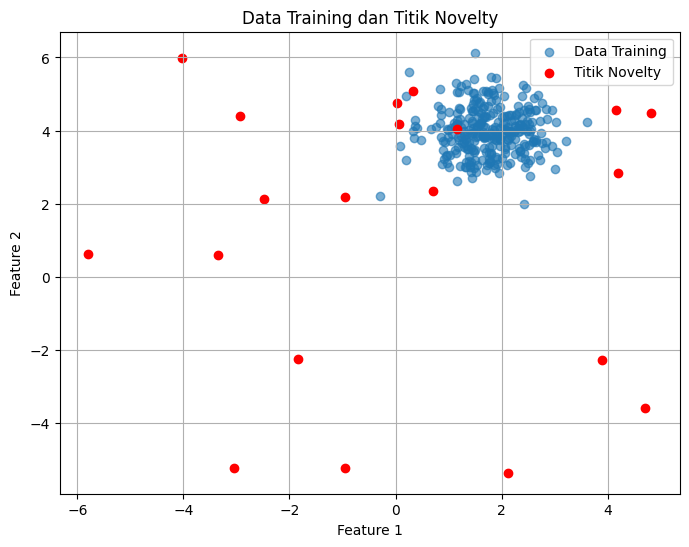

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_train[:, 0], X_train[:, 1],
    label='Data Training',
    alpha=0.6
)
plt.scatter(
    X_test_novelty[:, 0],
    X_test_novelty[:, 1],
    color='red',
    label='Titik Novelty'
)
plt.title("Data Training dan Titik Novelty")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

Data training hanya berisi data normal, sedangkan titik novelty baru muncul pada data test.

### Novelty detection menggunakan One-Class SVM

In [12]:
model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
model.fit(X_train)

OneClassSVM(nu=0.05)

In [13]:
y_pred = model.predict(X_test)

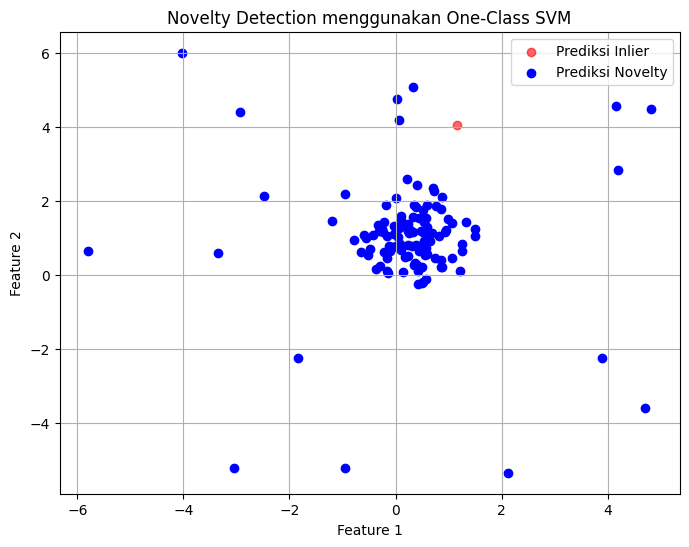

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_test[y_pred == 1, 0],
    X_test[y_pred == 1, 1],
    color='red',
    label='Prediksi Inlier',
    alpha=0.6
)
plt.scatter(
    X_test[y_pred == -1, 0],
    X_test[y_pred == -1, 1],
    color='blue',
    label='Prediksi Novelty'
)
plt.title("Novelty Detection menggunakan One-Class SVM")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

One-Class SVM memisahkan data normal dari origin pada ruang feature yang telah ditransformasi menggunakan decision function.

Parameter penting:

- **Kernel**: dapat menggunakan linear, polynomial, atau RBF. RBF umum dipakai karena dapat membuat batas non-linear.
- **Gamma**: mengatur pengaruh satu contoh training. Nilai rendah menghasilkan batas yang lebih halus, sedangkan nilai tinggi menghasilkan batas lebih ketat.
- **Nu**: mengatur trade-off antara false positive dan fleksibilitas model.

One-Class SVM belajar dari data normal saja dan dievaluasi pada data baru yang belum terlihat.

### Catatan tambahan One-Class SVM

- One-Class SVM sensitif terhadap scaling feature.
- `decision_function()` dapat digunakan untuk memperoleh skor jarak terhadap hyperplane.
- Pada dataset besar atau berdimensi tinggi, biaya komputasinya dapat tinggi.

## Detecting outliers with LOF

LOF adalah metode anomaly detection berbasis kepadatan yang membandingkan kepadatan lokal suatu titik dengan kepadatan lokal tetangganya. Jika sebuah titik berada di wilayah yang jauh lebih jarang dibandingkan tetangganya, titik tersebut dapat dianggap sebagai outlier.

### Membuat data dengan cluster berbeda kepadatan dan noise

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import LocalOutlierFactor

X, _ = make_blobs(
    n_samples=400,
    centers=[[0, 0], [5, 5]],
    cluster_std=[0.5, 1.5],
    random_state=2024
)

np.random.seed(2024)
outliers = np.random.uniform(low=-6, high=10, size=(20, 2))
X_with_outliers = np.vstack([X, outliers])

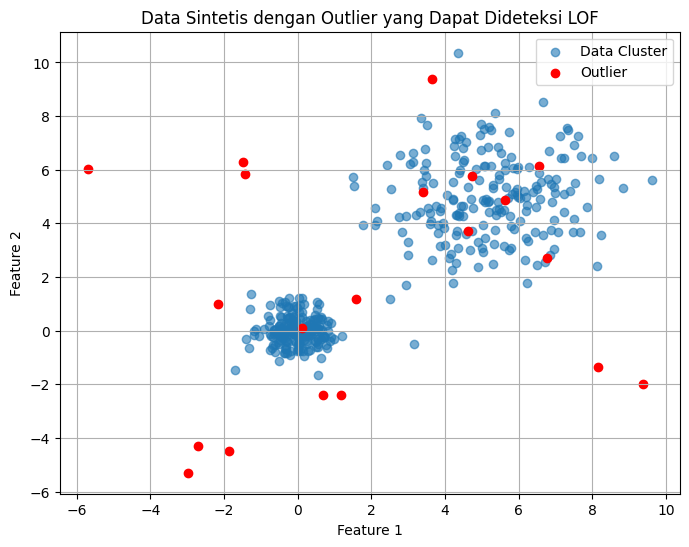

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X[:, 0], X[:, 1],
    label="Data Cluster",
    alpha=0.6
)
plt.scatter(
    outliers[:, 0], outliers[:, 1],
    color='red',
    label="Outlier"
)
plt.title("Data Sintetis dengan Outlier yang Dapat Dideteksi LOF")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

Dataset ini memiliki cluster dengan kepadatan berbeda dan tambahan outlier uniform.

### Deteksi anomali menggunakan LOF

In [17]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred = lof.fit_predict(X_with_outliers)

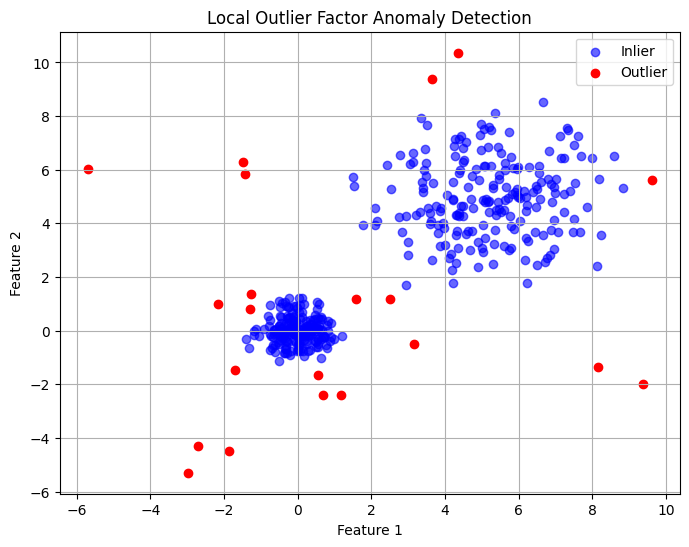

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_with_outliers[y_pred == 1, 0],
    X_with_outliers[y_pred == 1, 1],
    color='blue',
    label='Inlier',
    alpha=0.6
)
plt.scatter(
    X_with_outliers[y_pred == -1, 0],
    X_with_outliers[y_pred == -1, 1],
    color='red',
    label='Outlier'
)
plt.title("Local Outlier Factor Anomaly Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

LOF menghitung tingkat keanehan data berdasarkan:

- **Local density estimation**: kepadatan lokal dihitung dari jarak ke k-nearest neighbors.
- **Reachability distance**: jarak yang memperhalus pengaruh jarak aktual dan k-distance tetangga.
- **LOF score**: rasio kepadatan lokal tetangga terhadap kepadatan lokal titik tersebut. Nilai jauh di atas 1 mengarah pada outlier.

LOF tidak memiliki `.predict()` untuk data baru. Metode ini digunakan sebagai unsupervised anomaly detector pada data training.

### Catatan tambahan LOF

- `n_neighbors` mengatur sensitivitas terhadap variasi lokal.
- LOF cocok untuk data dengan kepadatan berbeda di berbagai wilayah.
- LOF tidak cocok untuk novelty detection karena tidak mendukung prediksi pada data baru.

## Evaluating outlier detection models

Evaluasi model outlier detection lebih rumit dibanding evaluasi supervised learning biasa karena outlier biasanya jarang dan label sering tidak tersedia. Jika label tersedia, evaluasi dapat menggunakan precision, recall, F1-score, ROC-AUC, dan confusion matrix.

### Membuat labeled synthetic data

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import seaborn as sns

X_inliers, _ = make_blobs(
    n_samples=300,
    centers=[[0, 0]],
    cluster_std=0.6,
    random_state=2024
)

X_outliers = np.random.uniform(low=-6, high=6, size=(30, 2))
X = np.vstack([X_inliers, X_outliers])
y_true = np.array(
    [0] * len(X_inliers) + [1] * len(X_outliers)
)  # 0 = inlier, 1 = outlier

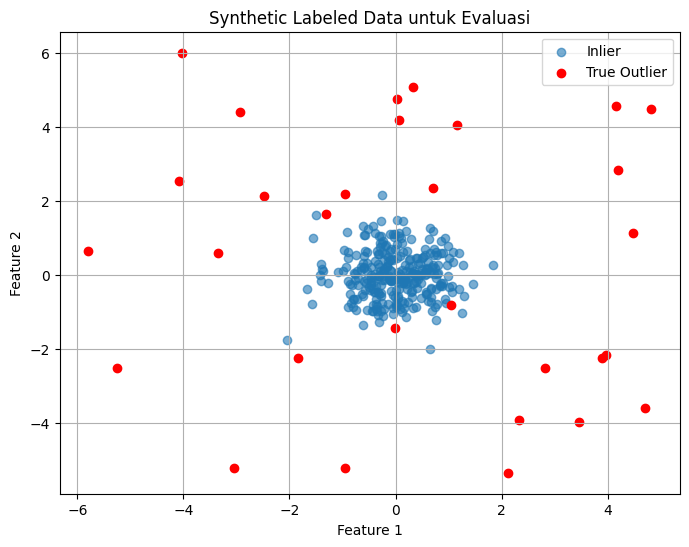

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X[y_true == 0][:, 0],
    X[y_true == 0][:, 1],
    label='Inlier',
    alpha=0.6
)
plt.scatter(
    X[y_true == 1][:, 0],
    X[y_true == 1][:, 1],
    color='red',
    label='True Outlier'
)
plt.title("Synthetic Labeled Data untuk Evaluasi")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

Dataset ini memiliki label asli: 0 untuk inlier dan 1 untuk outlier.

### Evaluasi Isolation Forest

In [21]:
model = IsolationForest(contamination=0.09, random_state=2024)
model.fit(X)
y_pred = model.predict(X)

y_pred_binary = np.where(
    y_pred == 1,
    0,
    1
)  # konversi ke 0 = inlier, 1 = outlier

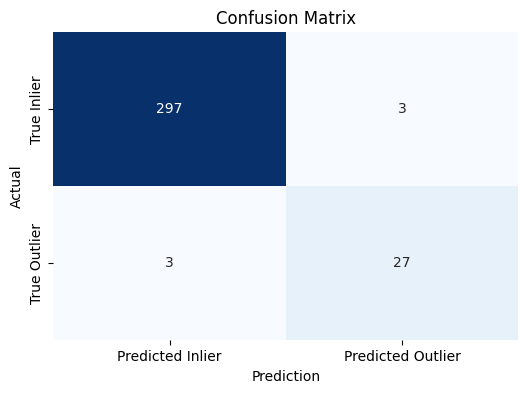

In [22]:
cm = confusion_matrix(y_true, y_pred_binary)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Predicted Inlier', 'Predicted Outlier'],
    yticklabels=['True Inlier', 'True Outlier']
)
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [23]:
report = classification_report(
    y_true,
    y_pred_binary,
    output_dict=True
)
report = pd.DataFrame(report).transpose()

styled_report = (report
    .style
    .background_gradient(
        cmap='Blues',
        subset=['precision', 'recall', 'f1-score']
    )
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

display(styled_report)
print("ROC-AUC Score:", roc_auc_score(y_true, model.decision_function(X)))

,precision,recall,f1-score,support
0,0.990,0.990,0.990,300
1,0.900,0.900,0.900,30
accuracy,0.982,0.982,0.982,1
macro avg,0.945,0.945,0.945,330
weighted avg,0.982,0.982,0.982,330


ROC-AUC Score: 0.005111111111111106


Makna metrik:

- **Precision**: proporsi prediksi outlier yang benar-benar outlier.
- **Recall**: proporsi outlier aktual yang berhasil ditemukan.
- **F1-score**: harmonic mean dari precision dan recall.
- **Confusion matrix**: ringkasan jumlah prediksi benar dan salah.
- **ROC-AUC**: kemampuan model membedakan outlier dan inlier berdasarkan skor.

### Catatan evaluasi

Pemilihan metrik harus disesuaikan dengan kasus. Pada fraud detection, false negative dapat lebih mahal daripada false positive. Threshold dari `decision_function()` juga dapat diatur untuk menyeimbangkan precision dan recall.

## Handling detected outliers

Setelah outlier terdeteksi, langkah berikutnya adalah menentukan cara menanganinya. Outlier dapat berupa informasi penting atau gangguan. Strategi yang umum digunakan antara lain removal, replacement, capping, dan flagging.

### Membuat dataset dan mendeteksi outlier

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs

X_inliers, _ = make_blobs(
    n_samples=300,
    centers=[[0, 0]],
    cluster_std=0.6,
    random_state=2024
)

X_outliers = np.random.uniform(low=-6, high=6, size=(30, 2))
X = np.vstack([X_inliers, X_outliers])

model = IsolationForest(contamination=0.09, random_state=2024)
model.fit(X)
outlier_mask = model.predict(X) == -1

### Strategi menangani outlier

In [25]:
# 1. Menghapus outlier dari dataset
X_cleaned = X[~outlier_mask]

# 2. Mengganti outlier dengan median per feature
X_replaced = X.copy()
median_vals = np.median(X[~outlier_mask], axis=0)
X_replaced[outlier_mask] = median_vals

# 3. Membatasi outlier ke batas tertentu atau winsorization
X_df = pd.DataFrame(X, columns=['feature1', 'feature2'])
X_capped = X_df.copy()

for col in X_df.columns:
    lower = X_df[col].quantile(0.05)
    upper = X_df[col].quantile(0.95)
    X_capped[col] = X_df[col].clip(lower=lower, upper=upper)

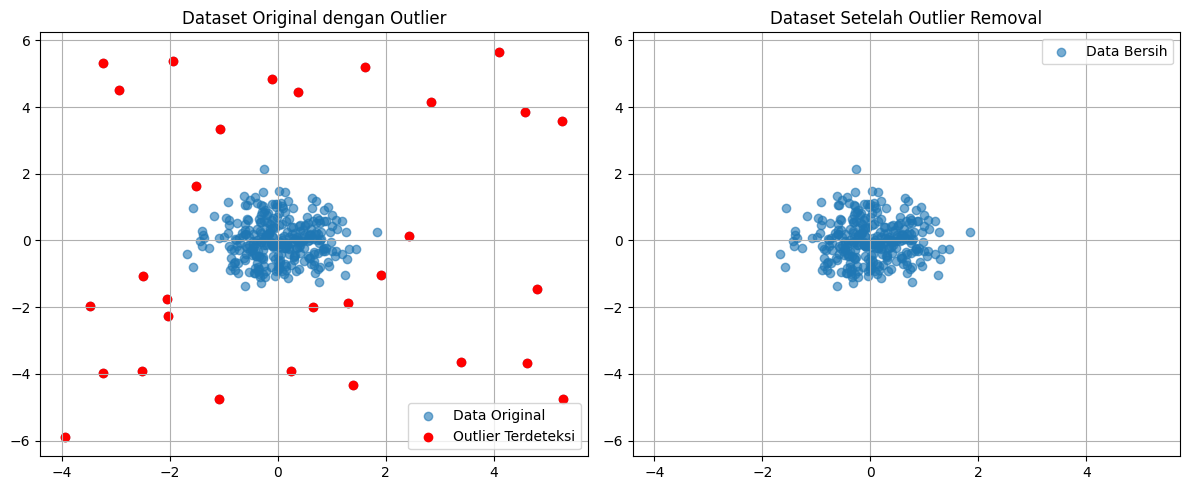

In [26]:
plt.figure(figsize=(12, 5))

ax1 = plt.subplot(1, 2, 1)
ax1.scatter(
    X[:, 0], X[:, 1],
    label='Data Original',
    alpha=0.6
)
ax1.scatter(
    X[outlier_mask][:, 0],
    X[outlier_mask][:, 1],
    color='red',
    label='Outlier Terdeteksi'
)
ax1.set_title('Dataset Original dengan Outlier')
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 2, 2)
ax2.scatter(
    X_cleaned[:, 0], X_cleaned[:, 1],
    label='Data Bersih',
    alpha=0.6
)
ax2.set_title('Dataset Setelah Outlier Removal')
ax2.legend()
ax2.grid(True)

ax2.set_xlim(ax1.get_xlim())
ax2.set_ylim(ax1.get_ylim())

plt.tight_layout()
plt.show()

Strategi penanganan outlier:

- **Removal**: cocok jika outlier berasal dari noise, error, atau data rusak.
- **Replacement**: mengganti outlier dengan mean, median, atau statistik pusat lain.
- **Capping / winsorization**: membatasi nilai ke rentang tertentu.
- **Flagging**: mempertahankan outlier, tetapi menambahkan indikator baru agar model dapat mempelajari perbedaannya.

### Catatan tambahan handling outlier

Keputusan menangani outlier sebaiknya tidak hanya berdasarkan statistik. Domain knowledge, validasi stakeholder, pipeline integration, dan pilihan antara imputation atau deletion perlu dipertimbangkan.

## Choosing the right detection technique

Pemilihan teknik outlier atau novelty detection bergantung pada karakteristik dataset, ada tidaknya label, kebutuhan prediksi data baru, skalabilitas, dimensionalitas, dan interpretabilitas.

### Tabel perbandingan metode

In [27]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

data = {
    "Algorithm": [
        "Isolation Forest",
        "Local Outlier Factor",
        "One-Class SVM"
    ],
    "Handles High Dimensions": ["Yes", "No", "Sometimes"],
    "Learns From Unlabeled Data": ["Yes", "Yes", "No (novelty only)"],
    "Supports New Predictions": ["Yes", "No", "Yes"],
    "Scales to Large Data": ["Yes", "No", "No"],
    "Robust to Varying Densities": ["No", "Yes", "Partially"],
    "Main Strength": [
        "Fast, scalable, easy to use",
        "Detects local anomalies in varying densities",
        "Kernel-based boundary modeling"
    ]
}

summary_df = pd.DataFrame(data)
summary_df.set_index("Algorithm", inplace=True)
summary_df

,Handles High Dimensions,Learns From Unlabeled Data,Supports New Predictions,Scales to Large Data,Robust to Varying Densities,Main Strength
Algorithm,,,,,,
Isolation Forest,Yes,Yes,Yes,Yes,No,"Fast, scalable, easy to use"
Local Outlier Factor,No,Yes,No,No,Yes,Detects local anomalies in varying densities
One-Class SVM,Sometimes,No (novelty only),Yes,No,Partially,Kernel-based boundary modeling


### Contoh pemilihan model berdasarkan kondisi data

In [28]:
# Jika data besar dan berdimensi tinggi, Isolation Forest dapat dipilih.
model = IsolationForest(contamination=0.1, random_state=2024)

In [29]:
# Jika data memiliki cluster dengan kepadatan berbeda, LOF lebih sesuai.
model = LocalOutlierFactor(n_neighbors=20, contamination=0.1)

In [30]:
# Jika training hanya memakai data normal dan ingin mendeteksi novelty nanti, gunakan One-Class SVM.
model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1)

Ringkasan pemilihan:

- **Isolation Forest**: cocok untuk deteksi outlier umum, dataset besar, dan dimensi tinggi.
- **LOF**: cocok untuk anomali lokal pada data dengan kepadatan tidak seragam, tetapi tidak bisa memprediksi data baru.
- **One-Class SVM**: cocok untuk novelty detection ketika hanya data normal tersedia saat training, tetapi sensitif terhadap scaling dan berat untuk dataset besar.

Jika ragu, materi menyarankan memulai dari Isolation Forest karena efisien, lalu iterasi sesuai kebutuhan domain.

### Catatan tambahan pemilihan teknik

- Hybrid strategy dapat menggabungkan beberapa model seperti LOF dan Isolation Forest.
- Explainability dapat menjadi pertimbangan, terutama jika model perlu dipahami oleh pengguna.
- Benchmarking dapat menggunakan precision-recall curve, ROC-AUC, atau kriteria khusus domain.

## Practical exercises in novelty and outlier detection

Bagian ini berisi latihan praktis dari materi. Karena bagian ini hanya memberikan langkah implementasi dan tidak memberikan kode lengkap, maka ditulis sebagai teori/daftar langkah.

### Exercise 1: Applying Isolation Forest to a real-world dataset

Langkah implementasi:

1. Load libraries.
2. Generate synthetic data dengan inlier dan outlier.
3. Scale data.
4. Apply Isolation Forest.
5. Evaluate results.
6. Print classification report sebagai styled DataFrame.

### Exercise 2: Using LOF on a network intrusion dataset

Langkah implementasi:

1. Load libraries.
2. Generate clustered data dengan synthetic noise.
3. Scale data.
4. Apply LOF.
5. Evaluate predictions.

### Exercise 3: One-Class SVM for manufacturing sensor data

Langkah implementasi:

1. Load libraries.
2. Generate normal dan novel data.
3. Fit One-Class SVM pada data normal.
4. Visualize predictions.